# Train GGPKD — full transition row, no negatives (Colab)

The candidate set is the anchor's **whole truncated transition row**: no quota, no
sampling, no RNG. `graph_k` is the only graph constant — it sets both the
neighbourhood width and the per-row bandwidth `tau_i = (s(1) - s(k)) / log(k)`,
so the k-th neighbour is exactly `k` times less likely than the nearest.

Replaces the earlier Top-K-only notebook. That one passed `--diffusion_quota 500`
against a pool holding ~67 positive columns per anchor, so the quota never bound
and the arm was mislabelled; the quota is gone entirely now.

In [29]:
#@title 1. Cấu hình experiment
REPO_URL = "https://github.com/Savoxism/AAAI-TALAS.git"
BRANCH = "nqd_ablation"

PAIR_KEY = "qwen3_4b_to_bert_base" #@param
# ["qwen3_0_6b_to_minilmv2_h384", "bge_m3_to_minilmv2_h768", "qwen3_4b_to_bert_base"]

# ---- Hằng số đồ thị: knob DUY NHẤT của phần graph ------------------------
# graph_k quyết định cả bề rộng láng giềng lẫn độ nhọn của hàng, vì bandwidth là
# tau_i = (s_i(1) - s_i(k)) / log(k). Một số, một hiệu ứng đơn điệu -- đó là lý do
# perplexity bị bỏ: phép giải entropic-affinity chạy trên bậc SAU lọc hai chiều,
# và 18.9% node có bậc <= 30 nên không bao giờ đạt được perplexity yêu cầu.
GRAPH_K = 200 #@param {type:"integer"}
DIFFUSION_SCALES = "1"  # paper protocol R={1}

# Candidate set = trọn hàng đã cắt. Không quota, không rút mẫu, không RNG.
# Bề rộng thực tế là fill của từng anchor và được cell 9 báo cáo.
DIFFUSION_QUOTA = None
HARD_NEG_K = 0
RANDOM_NEG_K = 0

ROW_WEIGHT = 1.0 #@param {type:"number"}
ROW_START_EPOCH = 1 #@param {type:"integer"}

RUN_NAME = "full_row_no_neg" #@param {type:"string"}

BATCH_SIZE = 64 #@param {type:"integer"}
EPOCHS = 5 #@param {type:"integer"}
# 3e-5 là arm thắng từ config; run 77.89 trước đó chạy 2e-5 và có chữ ký
# undertrain rõ (loss còn giảm ở epoch 4→5, student_top1 còn tăng).
LEARNING_RATE = 3e-5 #@param {type:"number"}
MAX_LENGTH = 256 #@param {type:"integer"}
SEED = 42 #@param {type:"integer"}
NUM_WORKERS = 4 #@param {type:"integer"}
TRAIN_DATA = "data/train_set/merged_3_data_5k_each.csv" #@param {type:"string"}

FINAL_WEIGHTS_ONLY = True #@param {type:"boolean"}
REQUIRE_GPU = True #@param {type:"boolean"}

USE_GOOGLE_DRIVE = False #@param {type:"boolean"}
DRIVE_ROOT = "/content/drive/MyDrive/embedding-kd-runs" #@param {type:"string"}

# Thêm CLI flags không liên quan allocation nếu cần. Các flag định nghĩa arm bị
# khoá trong cell train để EXTRA_ARGS không vô tình override.
EXTRA_ARGS = "--direct_temp 0" #@param {type:"string"}

assert ROW_WEIGHT >= 0, "ROW_WEIGHT phải không âm"
assert ROW_START_EPOCH >= 1, "ROW_START_EPOCH phải bắt đầu từ 1"
assert GRAPH_K >= 2, "graph_k phải lấy ít nhất 2 láng giềng"
assert DIFFUSION_QUOTA is None, "Notebook này là arm lấy trọn hàng"
assert HARD_NEG_K == 0 and RANDOM_NEG_K == 0, "Notebook này khoá negatives bằng 0"
assert DIFFUSION_SCALES == "1", "Arm này giữ canonical R={1}"
assert BATCH_SIZE > 0 and EPOCHS > 0 and MAX_LENGTH > 0

# Mỗi graph_k/seed ghi vào thư mục riêng để không đè lên run khác.
RUN_TAG = (
    f"{RUN_NAME}_w{ROW_WEIGHT:g}_e{ROW_START_EPOCH}"
    f"_r1_k{GRAPH_K}_h0_n0_lr{LEARNING_RATE:g}_seed{SEED}"
)


In [30]:
# 2. Clone lần đầu; các lần Run all sau luôn fetch/reset về đúng remote head
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/embedding-kd")


def git(*args, capture=False):
    command = ["git", "-C", str(REPO_DIR), *args]
    if capture:
        return subprocess.check_output(command, text=True).strip()
    print("+", " ".join(command))
    subprocess.run(command, check=True)


if (REPO_DIR / ".git").is_dir():
    before = git("rev-parse", "HEAD", capture=True)
    git("remote", "set-url", "origin", REPO_URL)
    # Fetch tường minh BRANCH thay vì dựa vào refspec của `clone --single-branch`:
    # clone cũ chỉ theo dõi đúng một nhánh, nên đổi BRANCH ở cell 1 rồi rerun sẽ
    # làm `checkout origin/<BRANCH mới>` fail vì ref đó chưa bao giờ được fetch.
    git("fetch", "--prune", "origin",
        f"+refs/heads/{BRANCH}:refs/remotes/origin/{BRANCH}")
    git("checkout", "-B", BRANCH, f"origin/{BRANCH}")
    # `reset --hard` bỏ sửa đổi tracked; `clean -fd` bỏ file untracked còn sót từ
    # commit cũ. `clean -fd` KHÔNG đụng file bị .gitignore, nên cache/, logs/,
    # models/ vẫn nguyên -- đừng bao giờ thêm -x vào đây, teacher cache và graph
    # artifact nằm trong số đó và sẽ phải tính lại từ đầu.
    git("reset", "--hard", f"origin/{BRANCH}")
    git("clean", "-fd")
    after = git("rev-parse", "HEAD", capture=True)
    moved = "đã cập nhật" if before != after else "đã là mới nhất"
    print(f"Clone sẵn có: {before[:12]} -> {after[:12]}  ({moved})")
elif REPO_DIR.exists() and any(REPO_DIR.iterdir()):
    raise RuntimeError(f"{REPO_DIR} tồn tại nhưng không phải Git repository")
else:
    # Không dùng --single-branch: giữ refspec đầy đủ để lần sau đổi BRANCH vẫn fetch được.
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, REPO_URL, str(REPO_DIR)],
        check=True,
    )

# Khẳng định code đang chạy đúng bằng remote head, thay vì chỉ in ra rồi tin.
head = git("rev-parse", "HEAD", capture=True)
remote_head = git("rev-parse", f"origin/{BRANCH}", capture=True)
if head != remote_head:
    raise RuntimeError(
        f"HEAD ({head[:12]}) khác origin/{BRANCH} ({remote_head[:12]}) -- "
        "code đang chạy không phải bản trên GitHub"
    )
print(f"Ready: {BRANCH}@{head[:12]} — {git('log', '-1', '--pretty=%s', capture=True)}")


+ git -C /content/embedding-kd remote set-url origin https://github.com/Savoxism/AAAI-TALAS.git
+ git -C /content/embedding-kd fetch --prune origin +refs/heads/nqd_ablation:refs/remotes/origin/nqd_ablation
+ git -C /content/embedding-kd checkout -B nqd_ablation origin/nqd_ablation
+ git -C /content/embedding-kd reset --hard origin/nqd_ablation
+ git -C /content/embedding-kd clean -fd
Clone sẵn có: a5cc823ff3a1 -> a5cc823ff3a1  (đã là mới nhất)
Ready: nqd_ablation@a5cc823ff3a1 — Refactor GGPKD candidate sampling and graph building for fixed bandwidth


In [31]:
# 3. Cài/đồng bộ dependencies theo code vừa pull
import os
import sys

os.chdir(REPO_DIR)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_DIR / "requirements.txt")],
    check=True,
)
print("Dependencies are ready.")


Dependencies are ready.


In [32]:
# 4. Resolve model pair, GPU và nơi lưu artifacts
import torch

PAIR_CONFIGS = {
    "qwen3_0_6b_to_minilmv2_h384": {
        "teacher": "Qwen/Qwen3-Embedding-0.6B",
        "student": "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base",
        "pooling": "last_token",
    },
    "bge_m3_to_minilmv2_h768": {
        "teacher": "BAAI/bge-m3",
        "student": "nreimers/MiniLMv2-L6-H768-distilled-from-BERT-Base",
        "pooling": "cls",
    },
    "qwen3_4b_to_bert_base": {
        "teacher": "Qwen/Qwen3-Embedding-4B",
        "student": "google-bert/bert-base-uncased",
        "pooling": "last_token",
    },
}
pair = PAIR_CONFIGS[PAIR_KEY]

if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("Không tìm thấy CUDA GPU. Trong Colab chọn Runtime → Change runtime type → GPU.")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 2**30
    print(f"GPU: {props.name} ({vram_gb:.1f} GiB)")
    if PAIR_KEY == "qwen3_4b_to_bert_base" and vram_gb < 35:
        print("WARNING: Qwen3-4B ở cấu hình hiện tại có thể OOM trên GPU dưới khoảng 35 GiB.")

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    artifact_root = Path(DRIVE_ROOT)
else:
    artifact_root = REPO_DIR

# Teacher cache dùng chung. Graph cache mang cả r1 lẫn graph_k: bandwidth giờ
# suy ra từ graph_k, nên hai giá trị k khác nhau là hai artifact khác nhau.
cache_dir = artifact_root / "cache" / "ggpkd" / PAIR_KEY
log_dir = artifact_root / "logs" / "ggpkd" / PAIR_KEY
save_dir = artifact_root / "models" / "ggpkd" / PAIR_KEY / RUN_TAG
weights_dir = artifact_root / "models" / "ggpkd_weights" / PAIR_KEY / RUN_TAG
for path in (cache_dir, log_dir, save_dir, weights_dir):
    path.mkdir(parents=True, exist_ok=True)

print(f"Teacher: {pair['teacher']}")
print(f"Student: {pair['student']}")
print(f"Pooling: {pair['pooling']}")
print(f"Objective: L_rel + {ROW_WEIGHT} * L_row")
print(f"Row starts at epoch: {ROW_START_EPOCH}")
print(f"Diffusion scales: {DIFFUSION_SCALES}")
print(f"graph_k: {GRAPH_K}  (đặt cả bề rộng láng giềng lẫn bandwidth)")
print("Candidate set: trọn hàng transition đã cắt — không quota, không rút mẫu")
print(f"Outputs: {save_dir}")


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GiB)
Teacher: Qwen/Qwen3-Embedding-4B
Student: google-bert/bert-base-uncased
Pooling: last_token
Objective: L_rel + 1.0 * L_row
Row starts at epoch: 1
Diffusion scales: 1
graph_k: 200  (đặt cả bề rộng láng giềng lẫn bandwidth)
Candidate set: trọn hàng transition đã cắt — không quota, không rút mẫu
Outputs: /content/embedding-kd/models/ggpkd/qwen3_4b_to_bert_base/full_row_no_neg_w1_e1_r1_k200_h0_n0_lr3e-05_seed42


In [33]:
# 5. Train GGPKD
import shlex

extra_args = shlex.split(EXTRA_ARGS)
locked_flags = {"--support_policy", "--diffusion_quota", "--diffusion_scales",
                "--hard_neg_k", "--random_neg_k", "--graph_k", "--fixed_bandwidth"}
overrides = sorted(locked_flags.intersection(extra_args))
if overrides:
    raise ValueError(f"EXTRA_ARGS không được override các flag đã khóa: {overrides}")

command = [
    sys.executable, "main.py",
    "--method", "ggpkd",
    "--train_data", TRAIN_DATA,
    "--student_model", pair["student"],
    "--teacher_model", pair["teacher"],
    "--pooling_method", pair["pooling"],
    "--graph_k", str(GRAPH_K),
    "--diffusion_scales", DIFFUSION_SCALES,
    "--hard_neg_k", str(HARD_NEG_K),
    "--random_neg_k", str(RANDOM_NEG_K),
    "--row_weight", str(ROW_WEIGHT),
    "--row_start_epoch", str(ROW_START_EPOCH),
    "--batch_size", str(BATCH_SIZE),
    "--epochs", str(EPOCHS),
    "--eval_every", "0",
    "--lr", str(LEARNING_RATE),
    "--max_length", str(MAX_LENGTH),
    "--seed", str(SEED),
    "--num_workers", str(NUM_WORKERS),
    "--cache_path", str(cache_dir / "teacher_train.pt"),
    "--ggpkd_cache_path", str(cache_dir / f"graph_r1_k{GRAPH_K}.pt"),
    "--ggpkd_log_dir", str(log_dir),
    "--save_dir", str(save_dir),
    "--weights_dir", str(weights_dir),
]
if FINAL_WEIGHTS_ONLY:
    command.append("--final_weights_only")
if extra_args:
    command.extend(extra_args)

env = os.environ.copy()
env["TOKENIZERS_PARALLELISM"] = "false"
env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("+", shlex.join(command))
process = subprocess.Popen(
    command,
    cwd=REPO_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout:
    print(line, end="")
return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"Training failed with exit code {return_code}")


+ /usr/bin/python3 main.py --method ggpkd --train_data data/train_set/merged_3_data_5k_each.csv --student_model google-bert/bert-base-uncased --teacher_model Qwen/Qwen3-Embedding-4B --pooling_method last_token --graph_k 200 --diffusion_scales 1 --hard_neg_k 0 --random_neg_k 0 --row_weight 1.0 --row_start_epoch 1 --batch_size 64 --epochs 5 --eval_every 0 --lr 3e-05 --max_length 256 --seed 42 --num_workers 4 --cache_path /content/embedding-kd/cache/ggpkd/qwen3_4b_to_bert_base/teacher_train.pt --ggpkd_cache_path /content/embedding-kd/cache/ggpkd/qwen3_4b_to_bert_base/graph_r1_k200.pt --ggpkd_log_dir /content/embedding-kd/logs/ggpkd/qwen3_4b_to_bert_base --save_dir /content/embedding-kd/models/ggpkd/qwen3_4b_to_bert_base/full_row_no_neg_w1_e1_r1_k200_h0_n0_lr3e-05_seed42 --weights_dir /content/embedding-kd/models/ggpkd_weights/qwen3_4b_to_bert_base/full_row_no_neg_w1_e1_r1_k200_h0_n0_lr3e-05_seed42 --final_weights_only --direct_temp 0

Configuration for GGPKD method:
  task_type           

In [34]:
# 6. Xem artifacts và các metrics cuối
import json

print("Checkpoints:", save_dir)
print("Weights:", weights_dir)
metrics_path = save_dir / "metrics.jsonl"
if metrics_path.exists():
    records = [json.loads(line) for line in metrics_path.read_text().splitlines() if line.strip()]
    print(json.dumps(records[-1], indent=2, ensure_ascii=False) if records else "metrics.jsonl is empty")
else:
    print("Không tìm thấy metrics.jsonl")

Checkpoints: /content/embedding-kd/models/ggpkd/qwen3_4b_to_bert_base/full_row_no_neg_w1_e1_r1_k200_h0_n0_lr3e-05_seed42
Weights: /content/embedding-kd/models/ggpkd_weights/qwen3_4b_to_bert_base/full_row_no_neg_w1_e1_r1_k200_h0_n0_lr3e-05_seed42
{
  "method": "ggpkd",
  "run_id": "20260908-180353-91af75",
  "seed": 42,
  "test": {
    "avg": 78.51,
    "avg_in": 72.48,
    "avg_out": 81.53,
    "classification": {
      "data/test_set/banking77_test.csv": {
        "accuracy": 0.9203511053315995,
        "f1": 0.9201799274518917
      },
      "data/test_set/emotion_test.csv": {
        "accuracy": 0.7613293051359517,
        "f1": 0.6910762061079888
      },
      "data/test_set/tweet_test.csv": {
        "accuracy": 0.7400932400932401,
        "f1": 0.7440684283917701
      }
    },
    "pair": {
      "data/test_set/mrpc_test.csv": {
        "accuracy": 0.7286956521739131,
        "average_precision": 0.8430824233073848,
        "best_threshold": 0.9195979899497487,
        "f1": 0.

In [35]:
# 7. Phân tích run: run.json / metrics.jsonl / epochs.jsonl / step_metrics.jsonl
# Các file đều append-mode, nên mọi thứ được lọc theo run_id của run mới nhất
# (run.json bị ghi đè mỗi lần train nên luôn trỏ vào run vừa chạy).
import json
from pathlib import Path

import pandas as pd

RUN_DIR = Path(save_dir)  # save_dir đến từ cell 4; sửa tay nếu chạy cell này rời


def read_jsonl(path, run_id=None):
    path = Path(path)
    if not path.exists():
        return []
    rows = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    if run_id is not None:
        rows = [r for r in rows if r.get("run_id") == run_id]
    return rows


manifest = json.loads((RUN_DIR / "run.json").read_text())
run_id = manifest["run_id"]
cfg = manifest.get("config", {})
git = manifest.get("git", {})
graph = manifest.get("artifact", {}).get("graph_stats", {})

print(f"run_id      : {run_id}")
print(f"git         : {git.get('branch')}@{str(git.get('sha'))[:12]}"
      f"{' (DIRTY — sha không tái lập được run này)' if git.get('dirty') else ''}")
print("config      : " + ", ".join(
    f"{k}={cfg.get(k)}" for k in
    ("graph_k", "diffusion_scales", "diffusion_quota",
     "hard_neg_k", "random_neg_k",
     "row_weight", "row_start_epoch", "row_mode", "learning_rate",
     "epochs", "batch_size", "seed") if k in cfg))
expected_allocation = {
    "diffusion_quota": None,   # None = lấy trọn hàng, không có ngân sách
    "hard_neg_k": 0,
    "random_neg_k": 0,
    "graph_k": GRAPH_K,
}
mismatch = {k: (cfg.get(k), expected) for k, expected in expected_allocation.items()
            if cfg.get(k) != expected}
if mismatch:
    raise RuntimeError(f"Run không dùng đúng full-row allocation: {mismatch}")
if tuple(cfg.get("diffusion_scales", ())) != (1,):
    raise RuntimeError(f"Run không dùng canonical R={{1}}: {cfg.get('diffusion_scales')}")
if graph:
    print("graph_stats : " + ", ".join(f"{k}={v}" for k, v in sorted(graph.items())))

# ---- Bảng per-epoch: train means + geometry probe -------------------------
epochs = read_jsonl(RUN_DIR / "epochs.jsonl", run_id)
if epochs:
    rows = []
    for r in epochs:
        flat = {"epoch": r.get("epoch")}
        flat.update({k: v for k, v in (r.get("train") or {}).items()
                     if isinstance(v, (int, float))})
        flat.update({f"geo_{k}": v for k, v in (r.get("geometry") or {}).items()})
        if isinstance(r.get("test"), dict):
            flat["test_avg"] = r["test"].get("avg")
        rows.append(flat)
    df_epochs = pd.DataFrame(rows).set_index("epoch")

    train_cols = [c for c in (
        "loss", "loss_rel", "loss_row_weighted", "row_count", "row_exposed_mass",
        "row_valid_ratio", "target_entropy", "student_entropy",
        "student_entropy_ratio", "student_top1", "target_top1", "js_floor",
        "grad_norm", "mean_step_seconds") if c in df_epochs.columns]
    geo_cols = [c for c in (
        "geo_anisotropy", "geo_cos_std", "geo_effective_rank", "geo_uniformity",
        "geo_alignment", "geo_positive_cos_mean", "geo_separation",
        "geo_teacher_student_spearman", "geo_teacher_anisotropy") if c in df_epochs.columns]

    print("\n=== Train means theo epoch ===")
    display(df_epochs[train_cols].round(4))
    if geo_cols:
        print("=== Geometry probe theo epoch ===")
        display(df_epochs[geo_cols].round(4))
else:
    df_epochs = pd.DataFrame()
    print("\nKhông có dòng nào trong epochs.jsonl cho run này.")

# ---- Kết quả test cuối (eval_every=0 nên chỉ có một bản ở cuối run) --------
final = next((r for r in reversed(read_jsonl(RUN_DIR / "metrics.jsonl", run_id))
              if r.get("test")), None)
if final:
    t = final["test"]
    print(f"=== Test cuối ===  avg={t['avg']}  avg_in={t['avg_in']}  avg_out={t['avg_out']}")
    per_task = {}
    for domain in ("classification", "pair", "sts"):
        for path, res in (t.get(domain) or {}).items():
            name = Path(path).stem.replace("_test", "")
            if domain == "sts":
                per_task[name] = {"domain": "sts", "score": round(100 * res, 2)}
            else:
                key = "f1" if domain == "classification" else "average_precision"
                per_task[name] = {"domain": domain, "score": round(100 * res[key], 2),
                                  "f1": round(100 * res["f1"], 2)}
    display(pd.DataFrame(per_task).T)
else:
    print("Chưa có record test nào trong metrics.jsonl cho run này.")


run_id      : 20260908-180353-91af75
git         : nqd_ablation@a5cc823ff3a1
config      : graph_k=200, diffusion_scales=[1], diffusion_quota=None, hard_neg_k=0, random_neg_k=0, row_weight=1.0, row_start_epoch=1, learning_rate=3e-05, epochs=5, batch_size=64, seed=42
graph_stats : avg_degree=78.43975830078125, degenerate_bandwidth_rows=0, diffusion_capped_rows=0.0, diffusion_truncation_cum_r1=0.00847734415708401, diffusion_truncation_step1=0.008477344157084008, fallback_count=56, fallback_rate=0.00413192651073563, graph_k=200, hard_pool_fill_avg=200.0, hard_pool_fill_min=200.0, hub_edge_share_top1pct=0.0257625384020604, indegree_gini=0.40747535345777464, indegree_max=211.0, indegree_mean=78.43975503578544, indegree_p50=70.0, indegree_p99=199.0, isolated_indegree_rate=0.0037630045008485206, max_degree=200.0, min_degree=1.0, n_items=13553, pool_capped_rows=0.0, pool_empty_r1=0.0, pool_fill_avg=67.04633660444182, pool_fill_min=1.0, pool_residual_mass_r1=0.008105246244500172, pool_width=189

,loss,loss_rel,loss_row_weighted,row_count,row_exposed_mass,row_valid_ratio,target_entropy,student_entropy,student_entropy_ratio,student_top1,target_top1,js_floor,grad_norm,mean_step_seconds
epoch,,,,,,,,,,,,,,
1,1.7334,1.0155,0.7178,3374.4313,0.6281,0.9982,3.3235,3.0795,0.7909,0.2323,0.3498,0.0,NaN,1.5021
2,0.8268,0.4756,0.3512,3358.6114,0.6263,0.9981,3.3213,2.9303,0.7484,0.2786,0.3500,0.0,2.5998,1.4971
3,0.6422,0.3675,0.2748,3367.5213,0.6289,0.9981,3.3238,2.8726,0.7318,0.2975,0.3500,0.0,2.1582,1.5000
4,0.5644,0.3219,0.2425,3359.3697,0.6274,0.9981,3.3230,2.8434,0.7226,0.3073,0.3500,0.0,1.9480,1.5002
5,0.5298,0.3002,0.2295,3361.5687,0.6282,0.9981,3.3225,2.8325,0.7198,0.3109,0.3498,0.0,1.8086,1.4957


=== Geometry probe theo epoch ===


,geo_anisotropy,geo_cos_std,geo_effective_rank,geo_uniformity,geo_teacher_student_spearman,geo_teacher_anisotropy
epoch,,,,,,
1,0.5074,0.1064,466.4840,-1.8787,0.8112,0.3705
2,0.4845,0.1083,476.0104,-1.9685,0.8487,0.3705
3,0.4701,0.1096,481.5403,-2.0245,0.8632,0.3705
4,0.4655,0.1094,483.6555,-2.0433,0.8675,0.3705
5,0.4628,0.1103,484.8980,-2.0524,0.8704,0.3705


=== Test cuối ===  avg=78.51  avg_in=72.48  avg_out=81.53


,domain,score,f1
banking77,classification,92.02,92.02
emotion,classification,69.11,69.11
tweet,classification,74.41,74.41
mrpc,pair,84.31,67.01
scitail,pair,85.25,80.25
wic,pair,66.24,62.59
sick,sts,77.3,NaN
sts12,sts,75.88,NaN
stsb,sts,82.09,NaN


/tmp/ipykernel_6054/2338547375.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())


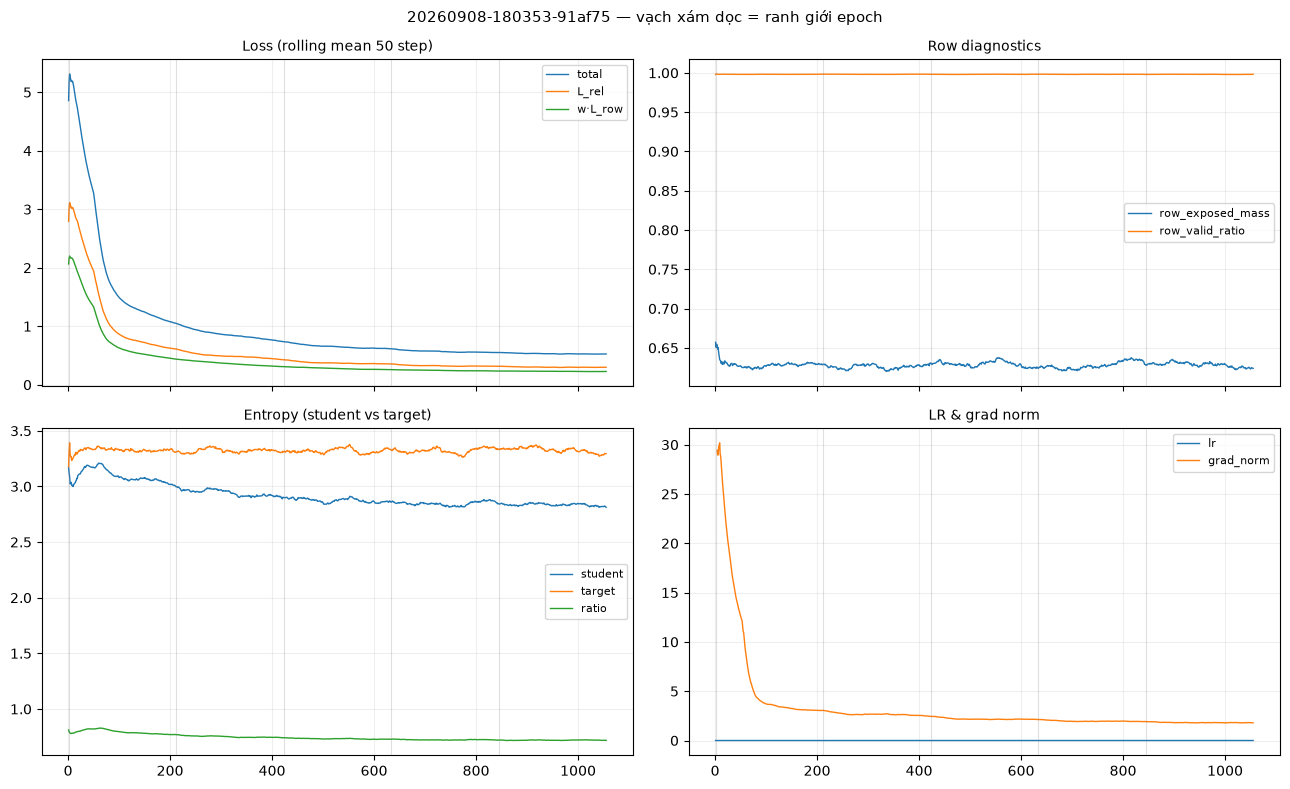

,first,last,mean,drop_in_epoch
epoch,,,,
1,4.8576,1.0125,1.7334,3.8451
2,0.9402,0.8086,0.8268,0.1316
3,0.7000,0.6440,0.6422,0.0560
4,0.5765,0.5420,0.5644,0.0345
5,0.5514,0.5585,0.5298,-0.0071


In [36]:
# 8. Đồ thị step-level từ step_metrics.jsonl
import matplotlib.pyplot as plt

steps = read_jsonl(RUN_DIR / "step_metrics.jsonl", run_id)
if not steps:
    raise SystemExit("Không có step_metrics.jsonl cho run này.")

df = pd.DataFrame(steps).sort_values("global_step").set_index("global_step")
smooth = lambda s, w=50: s.rolling(w, min_periods=1).mean()

panels = [
    ("Loss (rolling mean 50 step)",
     [("loss", "total"), ("loss_rel", "L_rel"), ("loss_row_weighted", "w·L_row")]),
    ("Row diagnostics",
     [("row_exposed_mass", "row_exposed_mass"), ("row_valid_ratio", "row_valid_ratio")]),
    ("Entropy (student vs target)",
     [("student_entropy", "student"), ("target_entropy", "target"),
      ("student_entropy_ratio", "ratio")]),
    ("LR & grad norm",
     [("lr_next", "lr"), ("grad_norm", "grad_norm")]),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
epoch_starts = df.groupby("epoch").apply(lambda g: g.index.min())
for ax, (title, series) in zip(axes.flat, panels):
    drawn = False
    for col, label in series:
        if col in df.columns and df[col].notna().any():
            ax.plot(smooth(df[col]), label=label, linewidth=1)
            drawn = True
    for e, s in epoch_starts.items():
        ax.axvline(s, color="gray", alpha=0.25, linewidth=0.8)
    ax.set_title(title, fontsize=10)
    if drawn:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.suptitle(f"{run_id} — vạch xám dọc = ranh giới epoch", fontsize=11)
fig.tight_layout()
plt.show()

# Nhìn nhanh: loss step đầu/cuối mỗi epoch, để thấy còn giảm hay đã phẳng
ep_summary = df.groupby("epoch")["loss"].agg(["first", "last", "mean"]).round(4)
ep_summary["drop_in_epoch"] = (ep_summary["first"] - ep_summary["last"]).round(4)
display(ep_summary)


In [37]:
# 9. Kiểm tra bandwidth và độ nhọn của hàng — CHẠY TRƯỚC KHI TIN KẾT QUẢ
# graph_k giờ đi thẳng vào objective qua tau_i = (s(1) - s(k)) / log(k), nên nó
# không còn là headroom vô hại như khi bandwidth do perplexity quyết định. Rủi ro
# cụ thể: nếu hàng ra quá phẳng thì L_rel thoái hoá thành bài toán nhị phân
# "láng giềng / không láng giềng" và mọi con số benchmark đều vô nghĩa.
import numpy as np
import torch

art = torch.load(str(cache_dir / f"graph_r1_k{GRAPH_K}.pt"), map_location="cpu")
pool_probs = art["pool_probs"].numpy()          # (n_scales, n_items, width)
pool_indices = art["pool_indices"].numpy()
row_temps = art["row_temps"].numpy()
n_items, width = pool_indices.shape

# ---- Bandwidth ------------------------------------------------------------
print(f"bandwidth mode : {art['metadata']['bandwidth']}  (graph_k={GRAPH_K})")
print(f"tau_i          : p50={np.median(row_temps):.4f}  p10={np.quantile(row_temps,.1):.4f}  "
      f"p90={np.quantile(row_temps,.9):.4f}  spread={row_temps.max()/row_temps.min():.1f}x")
print("  tham chiếu   : phép giải perplexity cũ cho p50=0.0535 nhưng spread 145x")
print("                 (2560/13553 hàng bị clamp vì bậc <= 30, tau vọt tới 7.76)")

# ---- Bề rộng candidate thực tế -------------------------------------------
fill = (pool_indices >= 0).sum(axis=1)
print(f"\ncột thật/anchor: mean={fill.mean():.1f}  min={fill.min()}  max={fill.max()}  "
      f"(row width khi collate = {width})")
print(f"  -> candidates_per_anchor trong log phải khớp {fill.mean():.1f}, không phải {width}")

# ---- Độ nhọn: đây là thứ cần xác minh ------------------------------------
# KL(p || uniform trên support) = log|supp| - H(p). Ngưỡng cảnh báo của build là
# 0.05; đồ thị perplexity cũ train ở 0.757.
p1 = pool_probs[0].astype(np.float64)
supp = (p1 > 0).sum(axis=1)
with np.errstate(divide="ignore", invalid="ignore"):
    ent = -np.where(p1 > 0, p1 * np.log(np.maximum(p1, 1e-300)), 0.0).sum(axis=1)
kl_unif = np.log(np.maximum(supp, 1)) - ent
eff_perp = np.exp(ent)

print(f"\nKL(p||uniform)  : p50={np.median(kl_unif):.3f}  p10={np.quantile(kl_unif,.1):.3f}  "
      f"p90={np.quantile(kl_unif,.9):.3f}")
print(f"perp hiệu dụng  : p50={np.median(eff_perp):.1f}  (support p50={np.median(supp):.0f})")
print("  tham chiếu    : đồ thị perplexity=30 cũ -> KL=0.757, perp hiệu dụng=30")

degenerate = float((kl_unif < 0.05).mean())
if np.median(kl_unif) < 0.05:
    raise RuntimeError(
        f"Hàng target gần như đều (KL p50={np.median(kl_unif):.3f} < 0.05): L_rel đã "
        f"thoái hoá thành nhị phân láng giềng/không. HẠ graph_k rồi dựng lại graph."
    )
if np.median(kl_unif) < 0.3:
    print(f"\n  CẢNH BÁO: KL p50={np.median(kl_unif):.3f}, phẳng hơn nhiều so với 0.757 "
          f"mà các run trước train trên. Kết quả sẽ không so được trực tiếp;\n"
          f"  hạ graph_k để làm nhọn hàng lại (span = log k, k nhỏ hơn -> nhọn hơn).")
else:
    print(f"\n  OK: {degenerate:.1%} anchor dưới ngưỡng thoái hoá 0.05.")

# ---- Quy tắc "láng giềng thứ k kém k lần" ---------------------------------
# Kiểm tra trên chính hàng đã dựng: tỉ số xác suất giữa cột đầu và cột cuối của
# support không vượt quá k, vì span logit theo thiết kế là log(k).
top = p1.max(axis=1)
low = np.where(p1 > 0, p1, np.inf).min(axis=1)
ratio = top / low
print(f"\ntỉ số p_max/p_min trên support: p50={np.median(ratio):.1f} (trần thiết kế = k = {GRAPH_K})")


bandwidth mode : knn  (graph_k=200)
tau_i          : p50=0.0340  p10=0.0206  p90=0.0811  spread=13.4x
  tham chiếu   : phép giải perplexity cũ cho p50=0.0535 nhưng spread 145x
                 (2560/13553 hàng bị clamp vì bậc <= 30, tau vọt tới 7.76)

cột thật/anchor: mean=67.0  min=1  max=189  (row width khi collate = 189)
  -> candidates_per_anchor trong log phải khớp 67.0, không phải 189

KL(p||uniform)  : p50=1.031  p10=0.612  p90=1.520
perp hiệu dụng  : p50=19.8  (support p50=58)
  tham chiếu    : đồ thị perplexity=30 cũ -> KL=0.757, perp hiệu dụng=30

  OK: 1.4% anchor dưới ngưỡng thoái hoá 0.05.

tỉ số p_max/p_min trên support: p50=130.3 (trần thiết kế = k = 200)
